# 06 — K-Fold Cross Validation Strategies

## Theory

Cross-validation estimates how well a model generalises to unseen data by rotating which portion of the data is held out for validation.

### KFold
Splits data into $k$ equal folds, using each as a validation set once:
- `shuffle=True` randomises order before splitting — important for i.i.d. data
- Does NOT preserve temporal ordering → **inappropriate for time-series data**

### StratifiedKFold (for regression: stratify by target quantiles)
Ensures each fold has a representative distribution of the target variable.
- Useful when the target is highly skewed (prevents a fold from having only extreme values)
- For regression: stratify by `pd.qcut(y, k, labels=False)` as the stratification variable

### TimeSeriesSplit
Preserves temporal ordering: train on past, validate on future.
```
Fold 1: [===Train===] | [Val]
Fold 2: [====Train====] | [Val]
Fold 3: [=====Train=====] | [Val]
```
- Useful when the test set is strictly future data
- HDB Kaggle test set is a **random holdout**, not future data → KFold is more appropriate here

### KFold ← **Recommended for this challenge**
With `shuffle=True, random_state=42` every fold is a random held-out 20% — mirrors how Kaggle evaluates the test set.

In [1]:
import sys
sys.path.insert(0, '..')
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import KFold, StratifiedKFold, TimeSeriesSplit, cross_val_score
from sklearn.linear_model import Ridge
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

from src.pipeline import build_pipeline
from src.evaluate import rmse

DATA_DIR = Path('../data')
PLOT_DIR = Path('../outputs/plots')

train = pd.read_csv(DATA_DIR / 'train.csv')
TARGET = 'resale_price'
X = train.drop(columns=[TARGET])
y = train[TARGET]
print('Data loaded.')

Data loaded.


## 1. Visualise Split Strategies

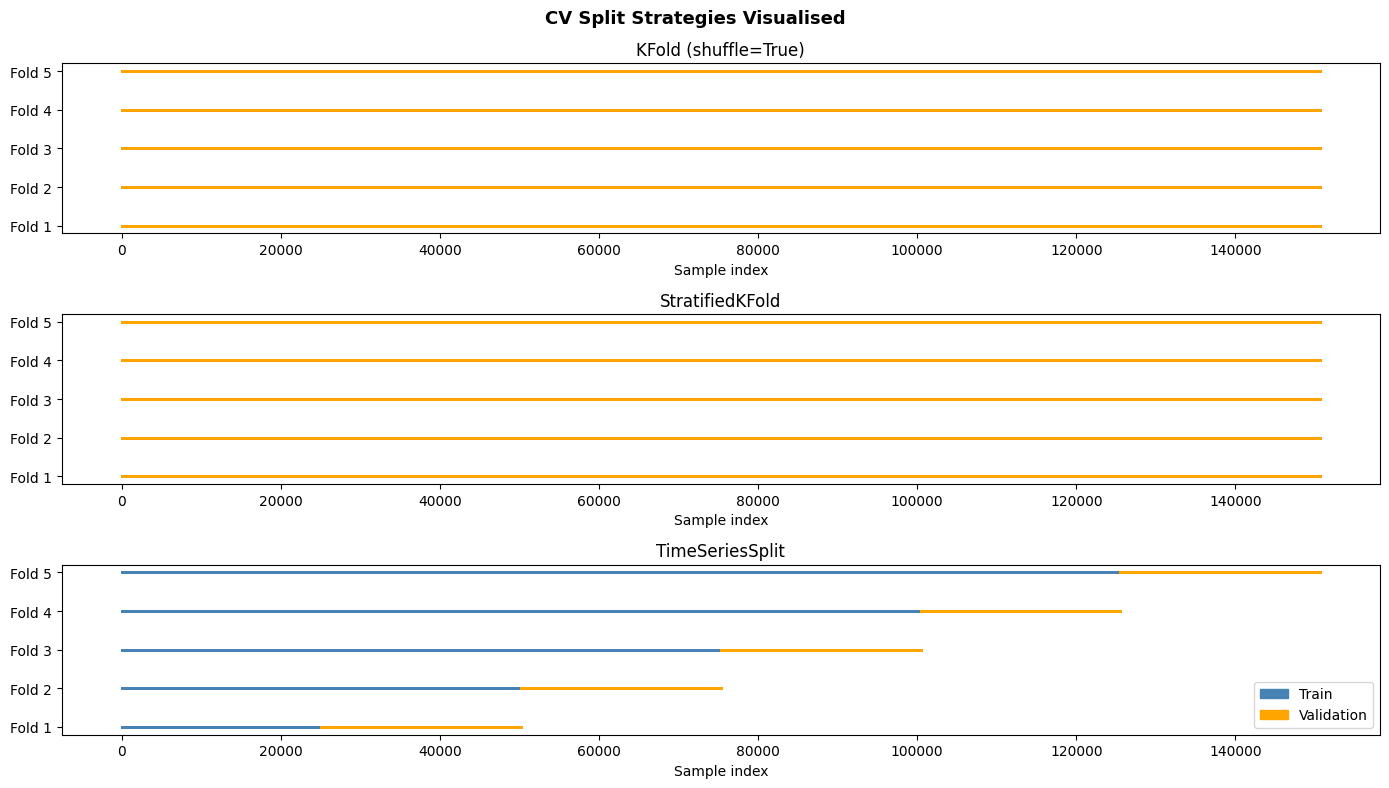

In [2]:
n_splits = 5
n_samples = len(X)

cv_strategies = {
    'KFold (shuffle=True)': KFold(n_splits=n_splits, shuffle=True, random_state=42),
    'StratifiedKFold': StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42),
    'TimeSeriesSplit': TimeSeriesSplit(n_splits=n_splits),
}

# Stratification variable for StratifiedKFold
y_strat = pd.qcut(y, n_splits, labels=False)

fig, axes = plt.subplots(3, 1, figsize=(14, 8))
for ax, (name, cv_obj) in zip(axes, cv_strategies.items()):
    for fold, (tr_idx, va_idx) in enumerate(cv_obj.split(X, y_strat)):
        ax.scatter(tr_idx, [fold] * len(tr_idx), c='steelblue', s=0.5, alpha=0.5)
        ax.scatter(va_idx, [fold] * len(va_idx), c='orange', s=0.5, alpha=0.8)
    ax.set_title(name)
    ax.set_xlabel('Sample index')
    ax.set_yticks(range(n_splits))
    ax.set_yticklabels([f'Fold {i+1}' for i in range(n_splits)])

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(color='steelblue', label='Train'),
                   Patch(color='orange', label='Validation')]
axes[-1].legend(handles=legend_elements, loc='lower right')

fig.suptitle('CV Split Strategies Visualised', fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig(PLOT_DIR / 'cv_splits_visualised.png', dpi=120)
plt.show()

## 2. Compare CV Strategies Across Models

In [4]:
# Use a subsample for speed in this demonstration
idx_sub = train.sort_values('Tranc_Year').index[:30000]
X_sub = X.loc[idx_sub].reset_index(drop=True)
y_sub = y.loc[idx_sub].reset_index(drop=True)
y_strat_sub = pd.qcut(y_sub, n_splits, labels=False)

pipelines = {
    'Ridge': build_pipeline(Ridge(alpha=10), mode='linear'),
    'LightGBM': build_pipeline(LGBMRegressor(n_estimators=200, random_state=42,
                                              n_jobs=-1, verbose=-1), mode='tree'),
}

cv_configs = {
    'KFold': KFold(n_splits=5, shuffle=True, random_state=42),
    'StratifiedKFold': StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    'TimeSeriesSplit': TimeSeriesSplit(n_splits=5),
}

results = []
for model_name, pipe in pipelines.items():
    for cv_name, cv_obj in cv_configs.items():
        # StratifiedKFold: pre-generate folds with quantile bins to avoid
        # cross_val_score passing continuous y to cv.split() internally
        if cv_name == 'StratifiedKFold':
            folds = list(cv_obj.split(X_sub, y_strat_sub))
            scores = cross_val_score(
                pipe, X_sub, y_sub, cv=folds,
                scoring='neg_root_mean_squared_error', n_jobs=-1)
        else:
            scores = cross_val_score(
                pipe, X_sub, y_sub, cv=cv_obj,
                scoring='neg_root_mean_squared_error', n_jobs=-1)
        rmse_scores = -scores
        results.append({
            'Model': model_name, 'CV Strategy': cv_name,
            'Mean RMSE': rmse_scores.mean(),
            'Std RMSE': rmse_scores.std(),
            'Fold Scores': rmse_scores.tolist()
        })
        print(f'{model_name} | {cv_name}: S${rmse_scores.mean():,.0f} ± S${rmse_scores.std():,.0f}')

results_df = pd.DataFrame(results)

Ridge | KFold: S$38,343 ± S$366
Ridge | StratifiedKFold: S$38,513 ± S$880
Ridge | TimeSeriesSplit: S$44,153 ± S$3,674
LightGBM | KFold: S$24,368 ± S$301
LightGBM | StratifiedKFold: S$24,251 ± S$542
LightGBM | TimeSeriesSplit: S$31,454 ± S$5,443


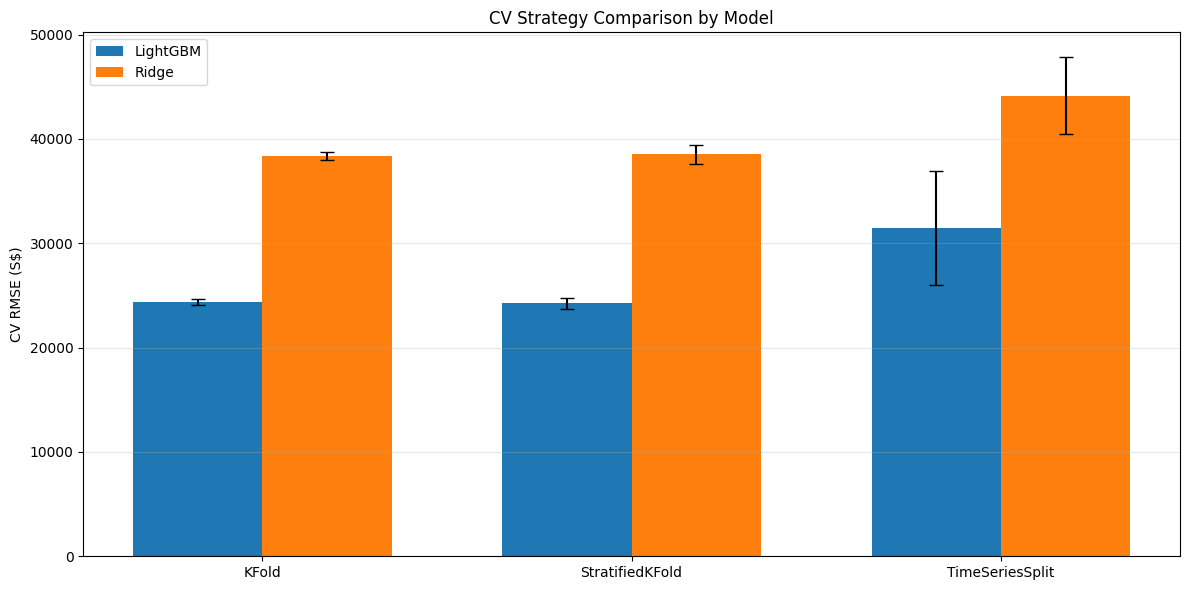

In [5]:
# Bar chart comparison
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(cv_configs))
width = 0.35

for i, (model_name, group) in enumerate(results_df.groupby('Model')):
    offset = (i - 0.5) * width
    bars = ax.bar(x + offset, group['Mean RMSE'].values, width,
                  label=model_name,
                  yerr=group['Std RMSE'].values, capsize=5)

ax.set_xticks(x)
ax.set_xticklabels(list(cv_configs.keys()))
ax.set_ylabel('CV RMSE (S$)')
ax.set_title('CV Strategy Comparison by Model')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
fig.tight_layout()
fig.savefig(PLOT_DIR / 'cv_strategy_comparison.png', dpi=120)
plt.show()

## 3. All Models — Final CV Comparison with KFold

In [6]:
from src.models import load_model
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression, Lasso, ElasticNet
from sklearn.ensemble import GradientBoostingRegressor

kfcv = KFold(n_splits=5, shuffle=True, random_state=42)

all_models = {
    'Linear Regression':    build_pipeline(LinearRegression(), mode='linear'),
    'Ridge':                build_pipeline(Ridge(alpha=10), mode='linear'),
    'Lasso':                build_pipeline(Lasso(alpha=0.1, max_iter=5000), mode='linear'),
    'ElasticNet':           build_pipeline(ElasticNet(alpha=0.1, l1_ratio=0.5), mode='linear'),
    'KNN (k=15)':           build_pipeline(KNeighborsRegressor(n_neighbors=15, n_jobs=-1), mode='linear'),
    'Decision Tree':        build_pipeline(DecisionTreeRegressor(max_depth=10, random_state=42), mode='tree'),
    'GradientBoosting':     build_pipeline(GradientBoostingRegressor(n_estimators=100, random_state=42), mode='tree'),
    'XGBoost':              build_pipeline(XGBRegressor(n_estimators=200, random_state=42, n_jobs=-1, verbosity=0), mode='tree'),
    'LightGBM':             build_pipeline(LGBMRegressor(n_estimators=200, random_state=42, n_jobs=-1, verbose=-1), mode='tree'),
}

cv_summary = []
for name, pipe in all_models.items():
    scores = cross_val_score(pipe, X_sub, y_sub, cv=kfcv,
                             scoring='neg_root_mean_squared_error', n_jobs=-1)
    rmse_scores = -scores
    cv_summary.append({'Model': name,
                        'CV RMSE Mean': rmse_scores.mean(),
                        'CV RMSE Std':  rmse_scores.std()})
    print(f'{name:<25}: S${rmse_scores.mean():,.0f} ± S${rmse_scores.std():,.0f}')

cv_summary_df = pd.DataFrame(cv_summary).sort_values('CV RMSE Mean')
cv_summary_df

Linear Regression        : S$38,156 ± S$367
Ridge                    : S$38,352 ± S$364


/home/shl/miniconda3/envs/hdb-price/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.890e+12, tolerance: 3.546e+10
  model = cd_fast.enet_coordinate_descent(
/home/shl/miniconda3/envs/hdb-price/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.829e+12, tolerance: 3.551e+10
  model = cd_fast.enet_coordinate_descent(
/home/shl/miniconda3/envs/hdb-price/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or co

Lasso                    : S$38,157 ± S$360
ElasticNet               : S$39,622 ± S$144
KNN (k=15)               : S$89,854 ± S$550
Decision Tree            : S$36,552 ± S$363
GradientBoosting         : S$32,487 ± S$275
XGBoost                  : S$23,438 ± S$267
LightGBM                 : S$24,277 ± S$372


,Model,CV RMSE Mean,CV RMSE Std
7,XGBoost,23437.970335,266.537682
8,LightGBM,24277.134061,372.467200
6,GradientBoosting,32486.927719,275.292939
5,Decision Tree,36552.107232,363.275805
0,Linear Regression,38155.876460,366.573830
2,Lasso,38156.684579,359.969202
1,Ridge,38352.168521,363.551285
3,ElasticNet,39621.735655,144.347973
4,KNN (k=15),89854.030205,550.007142


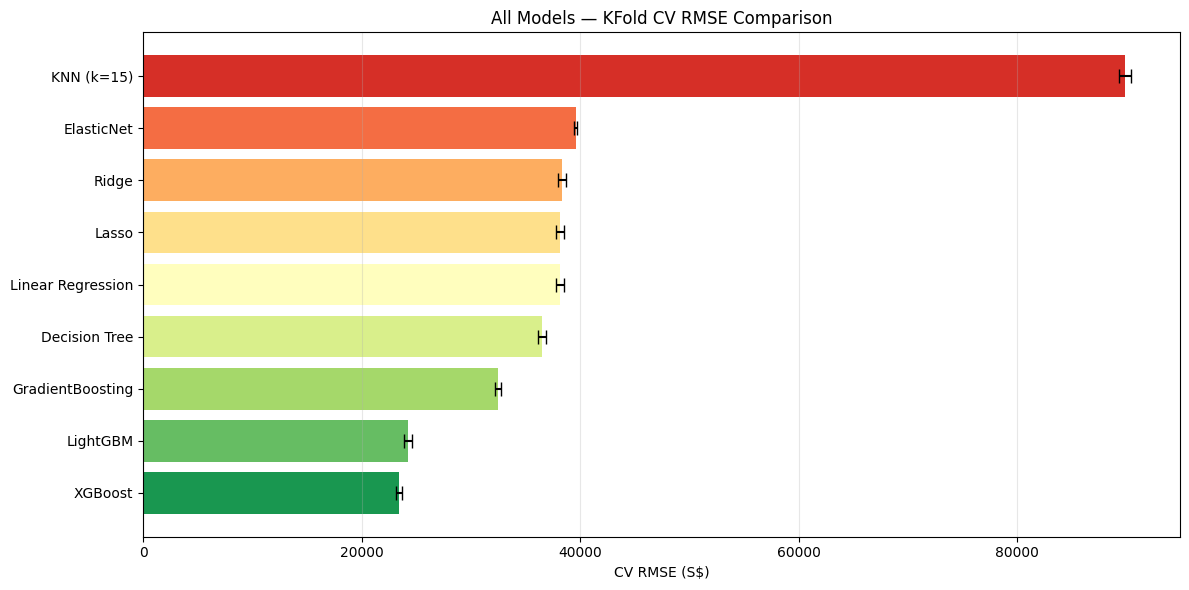

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(cv_summary_df)))
bars = ax.barh(cv_summary_df.Model, cv_summary_df['CV RMSE Mean'],
               xerr=cv_summary_df['CV RMSE Std'],
               color=colors, capsize=5)
ax.set_xlabel('CV RMSE (S$)')
ax.set_title('All Models — KFold CV RMSE Comparison')
ax.grid(True, alpha=0.3, axis='x')
fig.tight_layout()
fig.savefig(PLOT_DIR / 'all_models_cv_comparison.png', dpi=120)
plt.show()